# Single-subject pipeline

Set `SUBJECT_ID` and `CONDITION` in the next cell and run all cells.
You get: signal quality, ERP, epoch rejection stats, and classifier results.

Outputs are saved to `data/derived/`. Re-running a cell overwrites existing files.

In [1]:
# ---- CONFIGURE HERE -------------------------------------------------------
SUBJECT_ID  = '01'   # bare id, e.g. '01' or 'pilot-self-day0'
CONDITION   = 'control'           # the recording to visualise at load time
CHANNEL     = 'Cz'               # channel for ERP plot
CLASSIFIER  = 'swlda'            # 'lda' is fast, 'swlda' is the registered one
DATA_DIR    = 'data/raw'
DERIVED_DIR = 'data/derived'
# ---------------------------------------------------------------------------

In [2]:
import sys
import os
from pathlib import Path

# Find repo root by walking up until we find config.yaml.
# This works whether Jupyter starts from notebooks/ or from the repo root.
_here = Path('.').resolve()
repo_root = next(
    (p for p in [_here, _here.parent, _here.parent.parent]
     if (p / 'config.yaml').exists()),
    _here,
)
os.chdir(repo_root)
sys.path.insert(0, str(repo_root))
print(f'Working directory: {Path.cwd()}')

%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 120

from analysis.loader import load_recording
from analysis.preprocess import preprocess_recording
from analysis.classifier import train_and_evaluate
from analysis.plots import (
    plot_erp, plot_psd, plot_rejection_summary,
    plot_confusion_matrix, plot_condition_accuracy, plot_subject_summary,
)
print('Imports OK')

Working directory: G:\Coding_Workspaces_Masters
Imports OK


## 1. Load

In [3]:
rec = load_recording(SUBJECT_ID, CONDITION, data_dir=DATA_DIR, verbose_clock=True)

print(f'Subject:    sub-{rec.subject_id}')
print(f'Condition:  {rec.condition}')
print(f'Duration:   {rec.duration_s:.1f}s')
print(f'Markers:    {rec.n_epochs_planned}')
print(f'Clock fit:  m={rec.clock_fit[0]:.6f}  c={rec.clock_fit[1]*1000:.2f}ms')
print(f'EEG shape:  {rec.raw.get_data().shape}')

[loader] clock fit for 01/control: m=1.001240, c=-5.22ms | drift=-1.240ms/s | residual std=7.47ms
Subject:    sub-01
Condition:  control
Duration:   649.7s
Markers:    2571
Clock fit:  m=1.001240  c=-5.22ms
EEG shape:  (8, 162415)


## 2. Signal quality — raw PSD

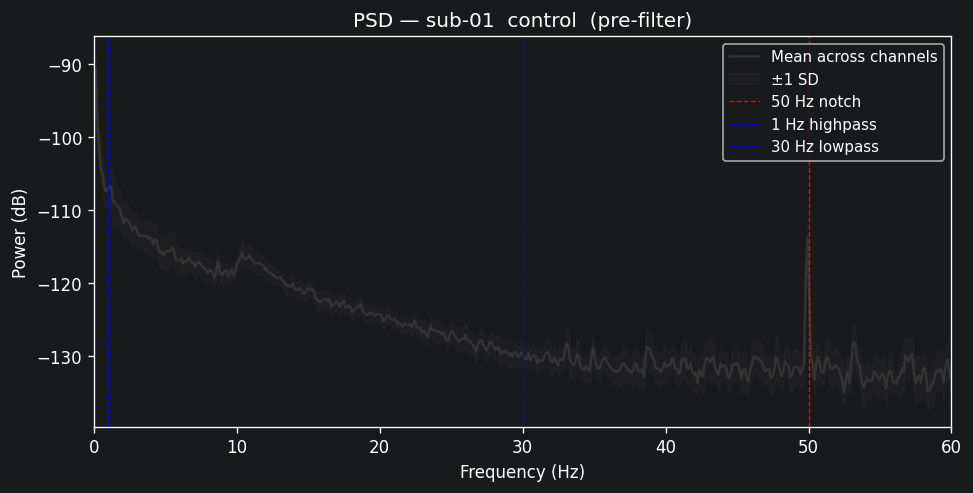

In [4]:
fig = plot_psd(rec.raw, title=f'PSD — sub-{SUBJECT_ID}  {CONDITION}  (pre-filter)')
plt.show()

## 3. Preprocess — filter, epoch, baseline-correct, reject

In [5]:
result = preprocess_recording(rec, save=True, derived_root=DERIVED_DIR)

log = result.rejection_log
print(f'Planned:           {log["n_planned"]}')
print(f'Boundary dropped:  {log["n_boundary_dropped"]}')
print(f'Amplitude dropped: {log["n_amplitude_dropped"]}')
print(f'Kept:              {log["n_kept"]}  ({(1-log["rejection_rate"])*100:.1f}%)')

Planned:           2571
Boundary dropped:  42
Amplitude dropped: 0
Kept:              2529  (98.4%)


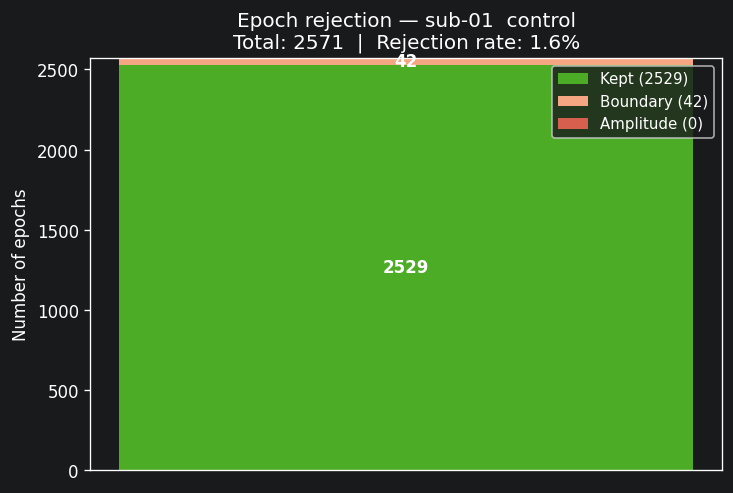

In [6]:
fig = plot_rejection_summary(result.rejection_log)
plt.show()

## 4. ERP — target vs nontarget

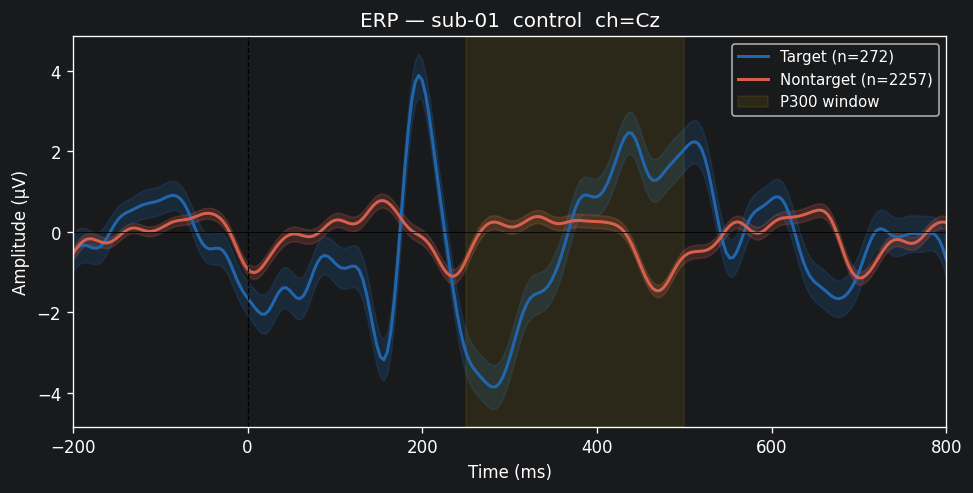

In [7]:
fig = plot_erp(result, channel=CHANNEL)
plt.show()

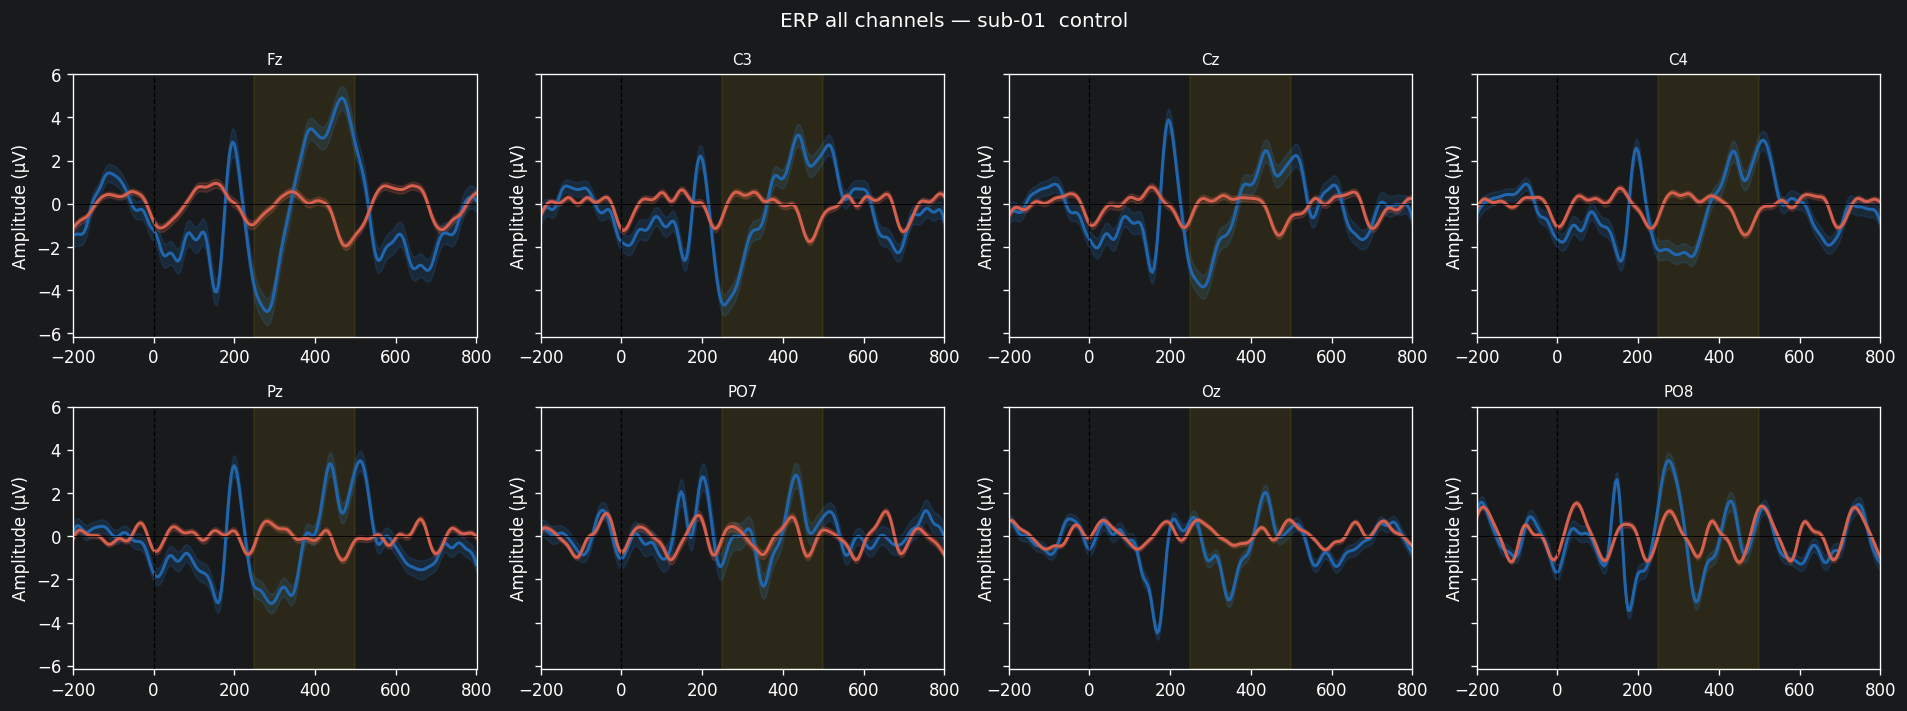

In [8]:
# All channels side by side — useful for checking spatial distribution of P300
fig, axes = plt.subplots(2, 4, figsize=(16, 6), sharey=True)
for ax, ch in zip(axes.flat, result.epochs.ch_names):
    plot_erp(result, channel=ch, ax=ax)
    ax.set_title(ch, fontsize=9)
    ax.set_xlabel('')
    ax.legend().remove()
fig.suptitle(f'ERP all channels — sub-{SUBJECT_ID}  {CONDITION}', fontsize=12)
fig.tight_layout()
plt.show()

## 5. Preprocess all four conditions

The classifier trains on control, so we need all four preprocessed before running it.

In [12]:
ALL_CONDITIONS = ['control', 'chewing', 'emi', 'acoustic']
preprocess_results = {}

for cond in ALL_CONDITIONS:
    print(f'Preprocessing {cond}...')
    r = load_recording(SUBJECT_ID, cond, data_dir=DATA_DIR)
    pr = preprocess_recording(r, save=True, derived_root=DERIVED_DIR)
    preprocess_results[cond] = pr
    log = pr.rejection_log
    print(f'  kept {log["n_kept"]} / {log["n_planned"]}  '
          f'({(1-log["rejection_rate"])*100:.1f}% kept)')

print('\nAll conditions preprocessed and saved.')

Preprocessing control...
  kept 2529 / 2571  (98.4% kept)
Preprocessing chewing...
  kept 1003 / 1285  (78.1% kept)
Preprocessing emi...
  kept 1243 / 1285  (96.7% kept)
Preprocessing acoustic...
  kept 1243 / 1285  (96.7% kept)

All conditions preprocessed and saved.


## 6. Classifier — train on control, test on all

In [10]:
clf_result = train_and_evaluate(
    subject_id=SUBJECT_ID,
    classifier_type=CLASSIFIER,
    derived_root=DERIVED_DIR,
    save=True,
)

print(f'Classifier:    {clf_result.classifier_type}')
print(f'Features used: {clf_result.n_features}')
print(f'Train epochs:  {clf_result.n_train_epochs} '
      f'(target={clf_result.train_target_count}, '
      f'nontarget={clf_result.train_nontarget_count})')
print()
for cond, metrics in clf_result.per_condition.items():
    print(f'  {cond:<20} bal.acc={metrics["balanced_accuracy"]*100:.1f}%  '
          f'n={metrics["n_epochs"]}')

  + add feat 318 (p=0.0000), selected=1
  + add feat 367 (p=0.0000), selected=2
  + add feat 220 (p=0.0000), selected=3
  + add feat 369 (p=0.0000), selected=4
  + add feat 225 (p=0.0000), selected=5
  + add feat 375 (p=0.0000), selected=6
  + add feat 219 (p=0.0000), selected=7
  + add feat 18 (p=0.0000), selected=8
  + add feat 268 (p=0.0000), selected=9
  + add feat 379 (p=0.0000), selected=10
  + add feat 29 (p=0.0001), selected=11
  + add feat 235 (p=0.0002), selected=12
  + add feat 37 (p=0.0000), selected=13
  + add feat 385 (p=0.0001), selected=14
  + add feat 374 (p=0.0001), selected=15
  + add feat 224 (p=0.0000), selected=16
  + add feat 370 (p=0.0005), selected=17
  + add feat 265 (p=0.0029), selected=18
  + add feat 315 (p=0.0002), selected=19
  + add feat 177 (p=0.0031), selected=20
  + add feat 75 (p=0.0006), selected=21
  + add feat 272 (p=0.0005), selected=22
  + add feat 322 (p=0.0009), selected=23
  + add feat 334 (p=0.0029), selected=24
  + add feat 34 (p=0.0037), s

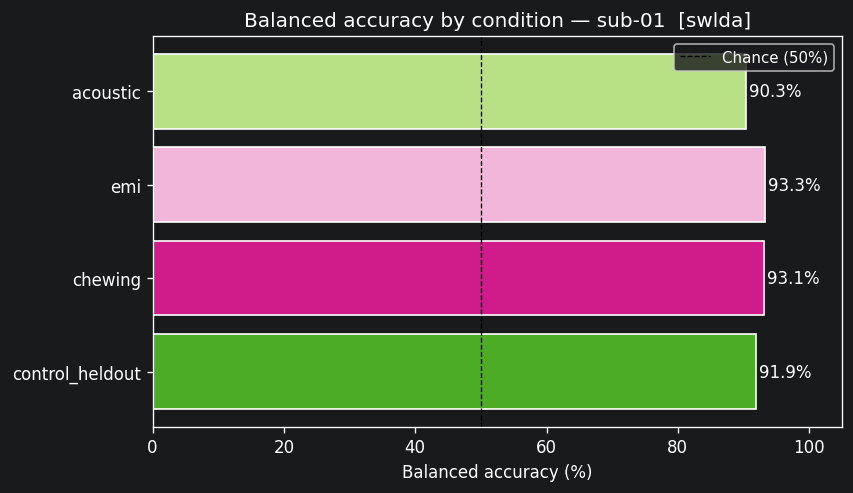

In [9]:
import json
from pathlib import Path

# Reload from disk so plot functions get the plain dict (not dataclass)
results_path = Path(DERIVED_DIR) / 'classifier-v2' / f'sub-{SUBJECT_ID}' / f'sub-{SUBJECT_ID}_results.json'
with open(results_path) as f:
    result_dict = json.load(f)

fig = plot_condition_accuracy(result_dict)
plt.show()

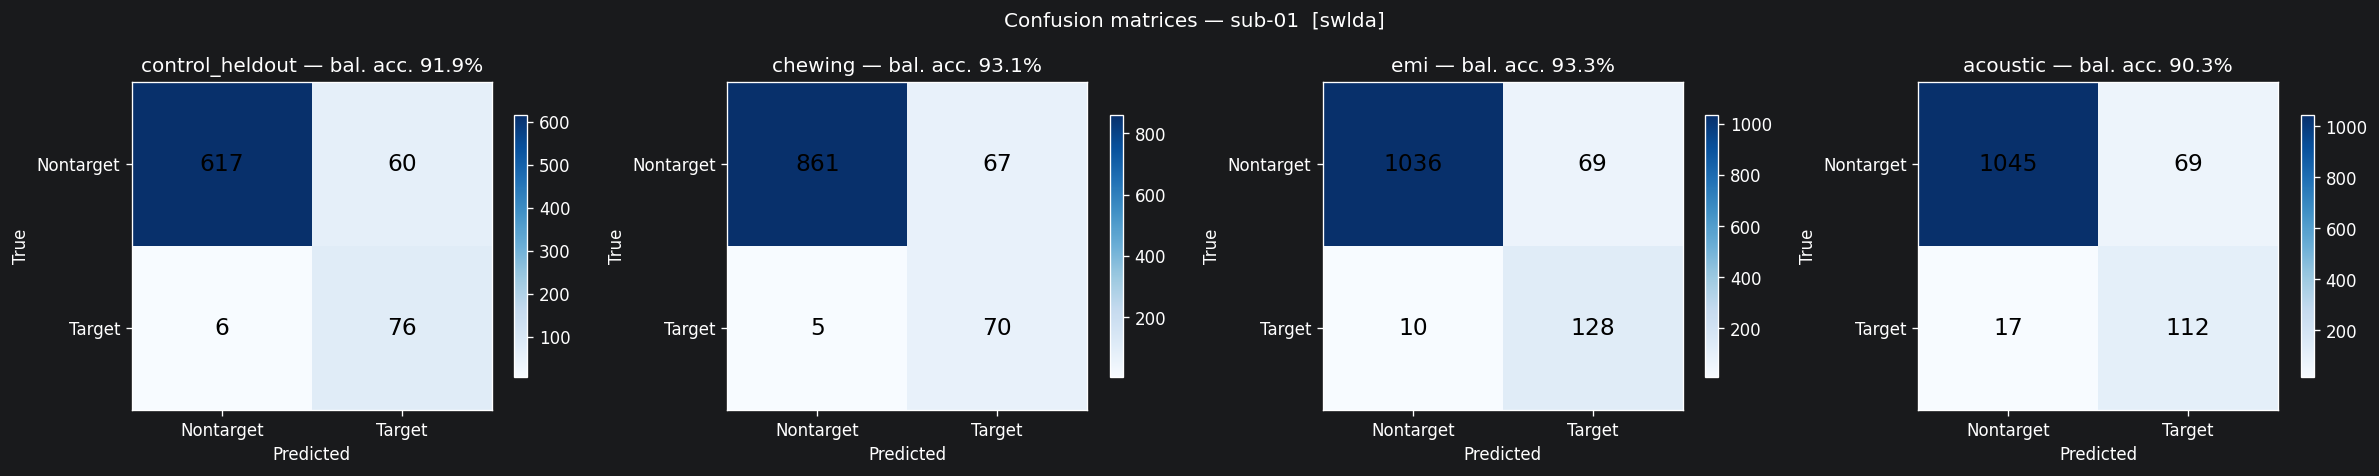

In [10]:
# Confusion matrices for all conditions
conditions = list(result_dict['per_condition'].keys())
fig, axes = plt.subplots(1, len(conditions), figsize=(5 * len(conditions), 4))
for ax, cond in zip(axes, conditions):
    plot_confusion_matrix(result_dict['per_condition'], cond, ax=ax)
fig.suptitle(f'Confusion matrices — sub-{SUBJECT_ID}  [{CLASSIFIER}]', fontsize=12)
fig.tight_layout()
plt.show()

## 7. One-page summary

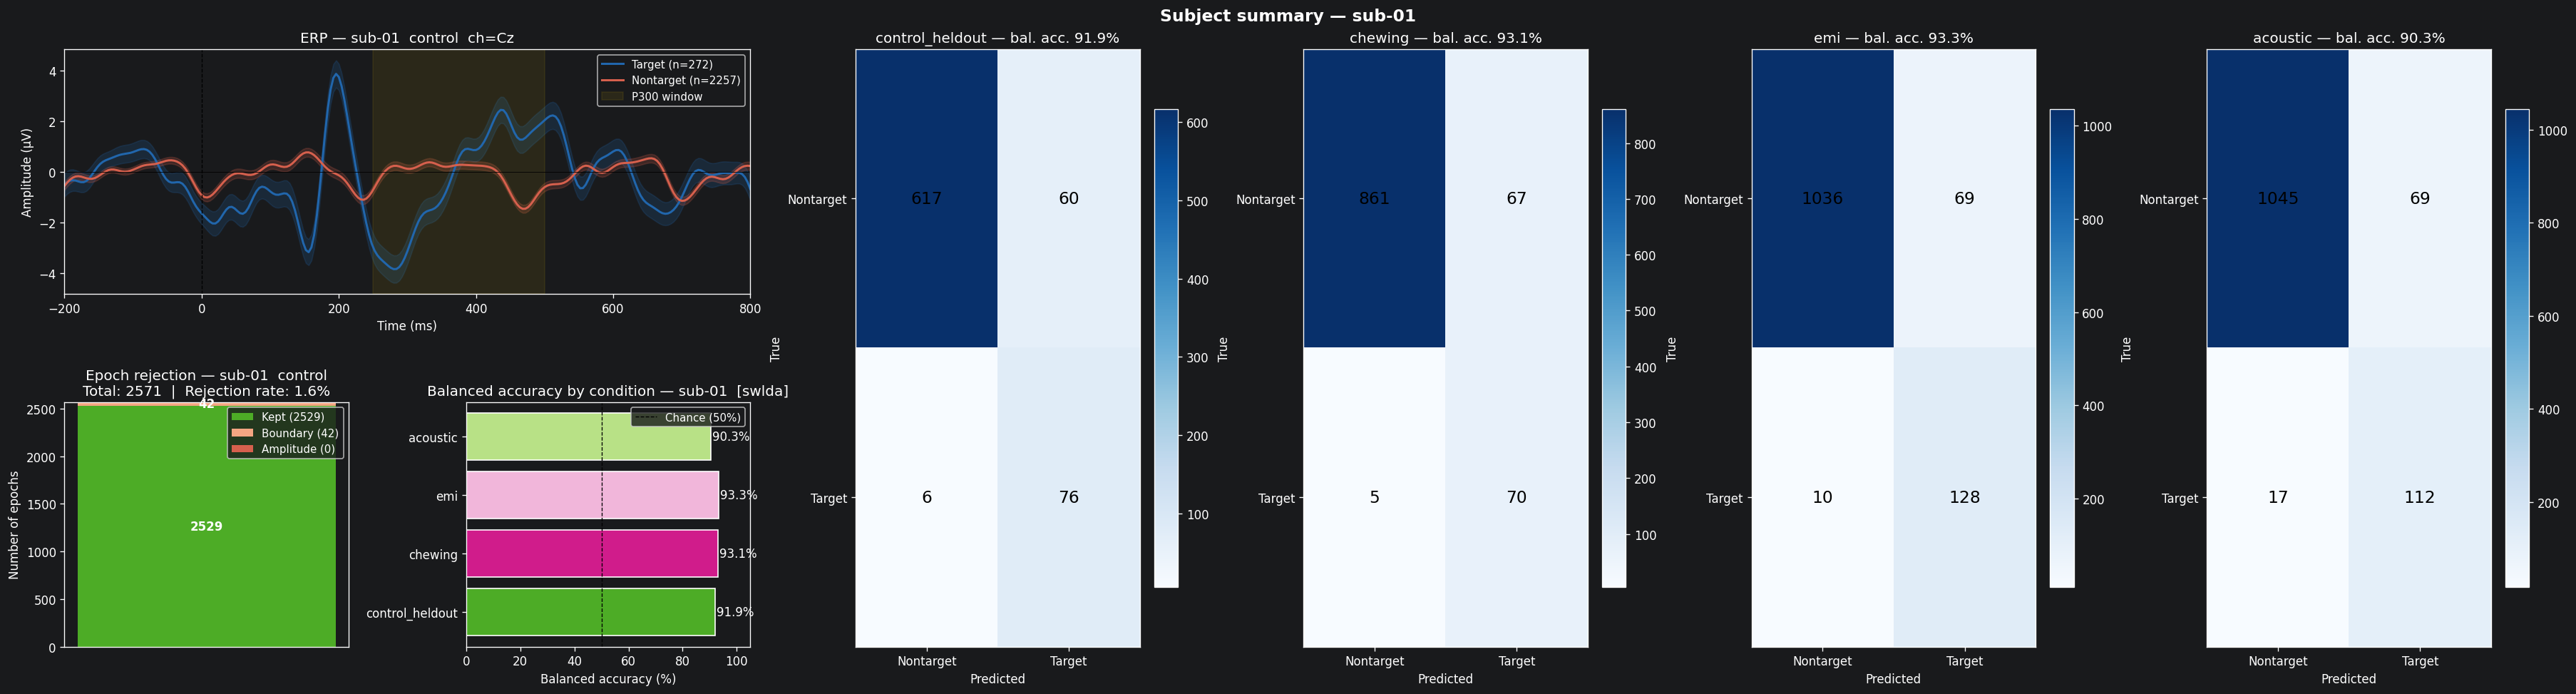

Saved: data\derived\sub-01_summary.png


In [13]:
# Uses the CONDITION recording preprocessed above (step 3)
fig = plot_subject_summary(preprocess_results[CONDITION], result_dict, channel=CHANNEL)
plt.show()

# Save it
out_path = Path(DERIVED_DIR) / f'sub-{SUBJECT_ID}_summary.png'
fig.savefig(out_path, dpi=150, bbox_inches='tight')
print(f'Saved: {out_path}')